# inclusão de bibliotecas e funções auxiliares

In [54]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
import pandas as pd
import control as ct

from numpy import pi

# ========================
# FUNCOES
# ========================= 

def plotData(timeVect,u,y,xylabels=[None,None],Datalegend=[None,None]):
    
    if u.any():
        plt.plot(timeVect, u, label=Datalegend[0], ls='--',color='black')
    plt.plot(timeVect,y, label=Datalegend[1])
    plt.xlabel(xylabels[0])
    plt.ylabel(xylabels[1])
    plt.grid()
    plt.legend()
    plt.show()

def rad_to_rpm(data):
    return ((60 * data)/(2*pi))



# Vetor Tempo de Simulação

In [55]:
timeMax = 0.4
Samples = 1000*timeMax

timeVect = np.linspace(0, timeMax, int(Samples))

# ================================
# Entrada da planta
# ================================

# Valor de entrada (tensao)
uVolts = np.zeros_like(timeVect)
uVolts[timeVect >= 0] = 3.92

# Parâmetros de Projeto

In [56]:
Mp = 5 / 100
ts2 = 0.2
zeta = np.sqrt((np.log(Mp)**2) / (np.pi**2 + np.log(Mp)**2))
wm = 4 / (ts2*zeta)

print(f'Mp = {Mp}')
print(f'ts (2%) = {ts2}')
print(f'Zeta = {zeta}')
print(f'wm (rad/s) = {wm}')

real = zeta*wm
imag = wm*np.sqrt(1-zeta**2)

polos = np.array([-real+imag*1j, -real-imag*1j, -real*4])

print(f'polos = {polos}')

Mp = 0.05
ts (2%) = 0.2
Zeta = 0.6901067305598216
wm (rad/s) = 28.981024404407407
polos = [-20.+20.97378782j -20.-20.97378782j -80. +0.j        ]


# Espaço de Estados do motor

In [57]:
# ================================
# Modelagem por Espaco de Estados
# ================================

Ra = 2.6 #Ohm
La = 0.006245 #H
J = 0.0002
B = 1.9e-3
Ke = 0.31
Kt = Ke
Kte = Kt

# x = [wa, theta]
# wm -> Velocidade (rad/s) do rotor
# theta -> Posicao (rad) do rotor
A = np.array([
    [-(Kte**2)/(J*Ra) - B/J, 0],
    [1, 0]
])

B = np.array([[Kte/(J*Ra)],[0]])

# [wm theta]
C = np.array([[0,1]])

D = 0

print(f'Autovalores de A:\n{np.linalg.eigvals(A)}')

Autovalores de A:
[   0.         -194.30769231]


# Simulação em malha aberta

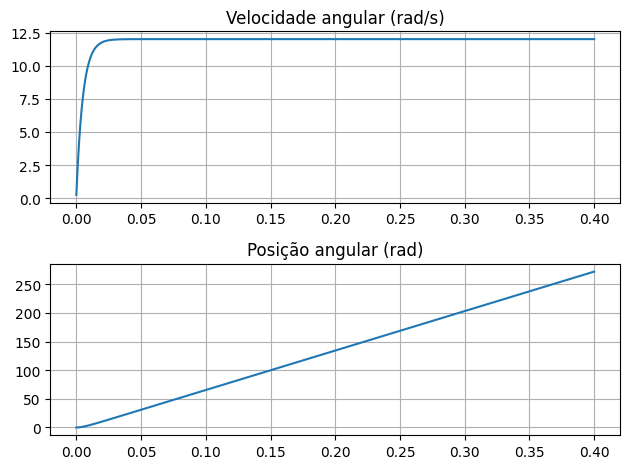

In [58]:
# x = [wm theta].T
timeSimulation = 0.4
dt = 1e-4

Samples = int(timeSimulation / dt)

x = np.array([[0],[0]])
x_history = np.zeros((2, Samples))
t = np.linspace(0, timeSimulation, Samples)

y = np.zeros((Samples))

for i in range(Samples):
    x_dot = A @ x + B * uVolts
    x = x + dt * x_dot
    x_history[:, i] = x[:,0]

    y[i] = (C @ x)[0, 0]

# Saídas
wm = x_history[0, :]
theta = x_history[1, :]

# Plot
plt.figure()
plt.subplot(2,1,1)
plt.plot(t, wm)
plt.title("Velocidade angular (rad/s)")
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, np.rad2deg(y))
plt.title("Posição angular (rad)")
plt.grid()

plt.tight_layout()
plt.show()

In [59]:
# ===============================
#  Novo Sistema
# ===============================

# Matriz de Controlabilidade
U = np.concatenate((B, A @ B), axis=1)
rank_U = np.linalg.matrix_rank(U)
print()
print("\nMatriz de Controlabilidade U:\n", U)
print()
print("Posto da Matriz de Controlabilidade:", rank_U)
print()

# Expandindo as matrizes para incluir o integrador
# e o estado erro
Ahat = np.concatenate((A, np.zeros((A.shape[0],1))), axis=1)
temp = np.concatenate((-C, np.array([[0]])), axis=1)
Ahat = np.concatenate((Ahat, temp), axis=0)
Bhat = np.concatenate((B, np.array([[0]])), axis=0)

del temp

# Ganho de realimentatacao e de integracao
Kvect = ct.acker(Ahat, Bhat, polos).reshape(3,1)
KI = Kvect[len(Kvect)-1]
K = np.copy(Kvect[0:len(Kvect)-1]).reshape(1,A.shape[0])

print("K:\n", K)
print("KI:\n", KI)

# Sistema aumentado acrecentado do 
# estado erro e ganho dos estados
A00 = A - (B * K)
A01 = B * -KI
A10 = -C
A11 = np.array([[0]])
    
Af = np.concatenate((A00, A01), axis=1)
temp = np.concatenate((A10, A11), axis=1)
Af = np.concatenate((Af, temp), axis=0)

print(f'autovalores de Af = {np.linalg.eigvals(Af)}')

del temp

Bf = np.array([[0],[0],[1]])
Cf = np.concatenate((C, np.array([[0]])), axis=1)
Df = np.array([[0]])



Matriz de Controlabilidade U:
 [[    596.15384615 -115837.27810651]
 [      0.             596.15384615]]

Posto da Matriz de Controlabilidade: 2

K:
 [[-0.12464516  6.77660608]]
KI:
 [-112.70913117]
autovalores de Af = [-80. +0.j         -20.+20.97378782j -20.-20.97378782j]


rad max: 4.09900316470426


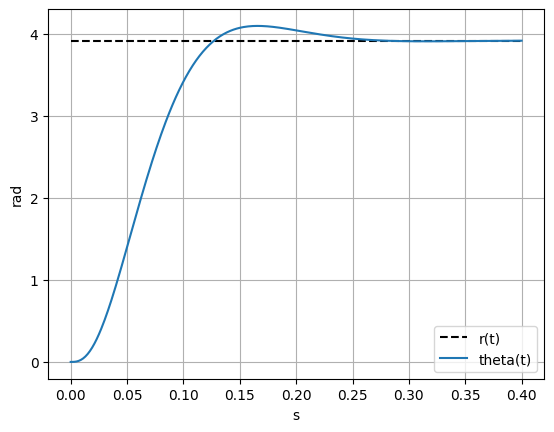

In [60]:
# ==========================
# Resposta coma realimentação e integrador
# ==========================

sys = signal.StateSpace(Af, Bf, Cf, Df)
t,y,x = signal.lsim(sys, U=uVolts, T=timeVect)

print(f'rad max: {np.max(y)}')

plotData(timeVect,uVolts,y, ['s','rad'], ['r(t)','theta(t)'])

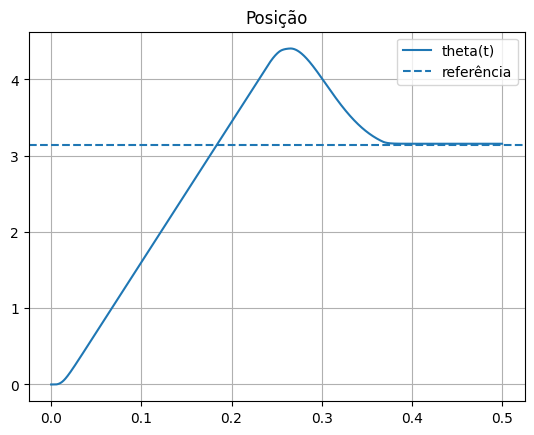

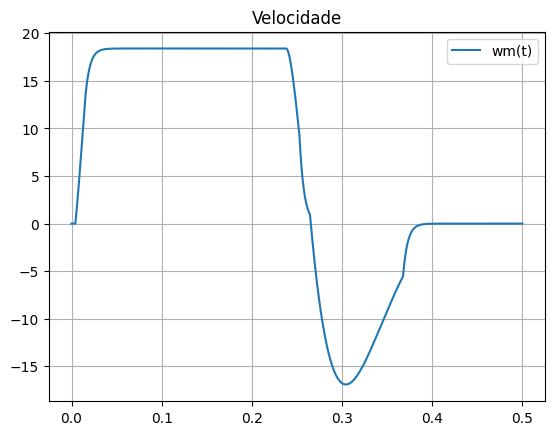

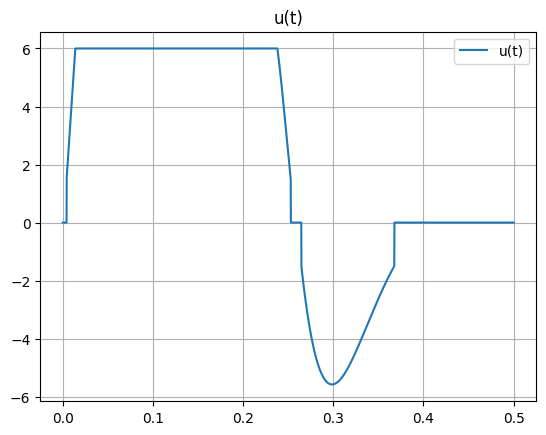

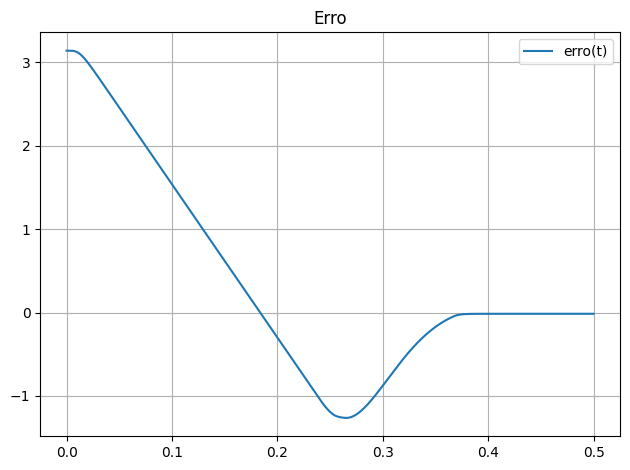

In [64]:
def saturate(u, u_min, u_max):
    return max(min(u, u_max), u_min)

def apply_deadzone_asym(u, dz_pos, dz_neg):
    if u > 0:
        if u < dz_pos:
            return 0.0
        else:
            return u 
    elif u < 0:
        if abs(u) < dz_neg:
            return 0.0
        else:
            return u 
    else:
        return 0.0

timeSimulation = 0.5
dt = 1e-4
Samples = int(timeSimulation / dt)

t = np.linspace(0, timeSimulation, Samples)

r = np.deg2rad(180)

# x = [wm theta erro].T
x = np.array([[0],[0],[0]])
x_history = np.zeros((3, Samples))
u_history = np.zeros((Samples))
y = np.zeros((Samples))

Kvect = Kvect.reshape(-1,1)  # garante (3,1)

Aa = np.block([
    [A, np.zeros((2, 1))],
    [-C, 0]
])

Bb = np.block([
    [B],[0]
])

Cc = np.block([[C, 0]])

for i in range(Samples):

    # Saída
    y[i] = (C @ x[:2])[0,0]

    # Controle
    u = -Kvect.T @ x
    u = u.item()

    # Zona morta assimétrica
    u = apply_deadzone_asym(u, 1.5, 1.5)

    # Saturação
    u = saturate(u, -6, 6)

    u_history[i] = u

    # Dinâmica
    x_dot = Aa @ x + Bb * u

    # Integrador: z_dot = r - y
    x_dot[2,0] = r - y[i]

    # Euler
    x = x + dt * x_dot

    x_history[:, i] = x[:,0]



wm = x_history[0, :]
theta = x_history[1, :]
erro = r - theta

plt.figure()
plt.plot(t, theta, label='theta(t)')
plt.axhline(r, linestyle='--', label='referência')
plt.legend()
plt.grid()
plt.title("Posição")

plt.figure()
plt.plot(t, wm, label='wm(t)')
plt.legend()
plt.grid()
plt.title("Velocidade")

plt.figure()
plt.plot(t, u_history, label='u(t)')
plt.legend()
plt.grid()
plt.title("u(t)")

plt.figure()
plt.plot(t, erro, label='erro(t)')
plt.legend()
plt.grid()
plt.title("Erro")

plt.tight_layout()
plt.show()